# Dual-head chess player

This notebook is wired for `dual1.pth` from `train_div_reg copy.ipynb`.

Run the setup cells once. Then use the ready-made cells at the bottom to play:

- model vs model
- model vs Stockfish
- you vs the model

The opening DB is optional. If `Games.npz`, a PGN, or a text move-list file is available, set `OPENING_DB_PATH` below or put `Games.npz` next to this notebook / in Downloads.


In [9]:
# Imports and device
from __future__ import annotations

import math
import os
import random
import re
import shutil
import time
from collections import Counter, OrderedDict, defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import chess
import chess.engine
import chess.pgn
import chess.polyglot
import chess.svg

from IPython.display import SVG, clear_output, display

if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)
print("python-chess:", getattr(chess, "__version__", "unknown"))
print("torch:", torch.__version__)


Using device: cuda
python-chess: 1.10.0
torch: 2.0.1+cu117


In [12]:
# Paths and knobs
HOME = Path.home()
DOWNLOADS = HOME / "Downloads"
OUT_DIR = DOWNLOADS / "chess_play_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Your uploaded checkpoint. Change this if you move it.
WEIGHTS_PATH =  Path("C:/Users/samue/OneDrive/Desktop/projects/ML/chess-learn/n6/weights/new_labels2.pth")

# Optional opening DB. Can be .npz with positions, .pgn, .txt/.uci/.san lines, or a polyglot .bin.
# Leave as None to auto-detect Games.npz in the current folder or Downloads.
OPENING_DB_PATH = None
OPENING_DB_MAX_GAMES = None
OPENING_BOOK_PLIES = 12

# Optional Stockfish binary. Leave as None to try PATH / common local names.
# Example: STOCKFISH_PATH = r"C:\path\to\stockfish.exe"
STOCKFISH_PATH = '../../n1/.ipynb_checkpoints/eval/stockfish/stockfish/stockfish-windows-x86-64-avx2.exe'

# Value target in training was sigmoid(cp / 400), so raw model value * 400 ~= centipawns.
VALUE_CP_SCALE = 400.0

# Search defaults. Increase depth on GPU/fast CPU; reduce if moves are slow.
DEFAULT_MODEL_DEPTH = 5
DEFAULT_STOCKFISH_DEPTH = 8
MAX_PLIES = 220
RANDOM_SEED = 7

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print("Weights:", WEIGHTS_PATH, "exists=", WEIGHTS_PATH.exists())
print("Output folder:", OUT_DIR)


Weights: C:\Users\samue\OneDrive\Desktop\projects\ML\chess-learn\n6\weights\new_labels2.pth exists= True
Output folder: C:\Users\samue\Downloads\chess_play_outputs


In [13]:
# Model definition exactly matching the training notebook
class ResBlock(nn.Module):
    def __init__(self, channels: int = 128):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x, inplace=True)
        x = self.conv2(x)
        x = self.bn2(x)
        x = x + residual
        x = F.relu(x, inplace=True)
        return x


class ChessNet(nn.Module):
    def __init__(self, in_ch: int = 19, filters: int = 128, num_blocks: int = 10, policy_dim: int = 4672):
        super().__init__()
        self.input_conv = nn.Conv2d(in_ch, filters, kernel_size=3, padding=1, bias=False)
        self.input_bn = nn.BatchNorm2d(filters)
        self.res_blocks = nn.Sequential(*[ResBlock(filters) for _ in range(num_blocks)])

        self.value_conv = nn.Conv2d(filters, 1, kernel_size=1, bias=False)
        self.value_bn = nn.BatchNorm2d(1)
        self.value_fc1 = nn.Linear(64, 64)
        self.value_fc2 = nn.Linear(64, 1)

        self.policy_conv = nn.Conv2d(filters, 2, kernel_size=1, bias=False)
        self.policy_bn = nn.BatchNorm2d(2)
        self.policy_fc = nn.Linear(2 * 8 * 8, policy_dim)

    def forward_features(self, x):
        x = self.input_conv(x)
        x = self.input_bn(x)
        x = F.relu(x, inplace=True)
        x = self.res_blocks(x)
        return x

    def forward_raw(self, x, legal_mask=None):
        x = self.forward_features(x)

        v = self.value_conv(x)
        v = self.value_bn(v)
        v = F.relu(v, inplace=True)
        v = v.view(v.size(0), -1)
        v = F.relu(self.value_fc1(v), inplace=True)
        v = self.value_fc2(v)

        p = self.policy_conv(x)
        p = self.policy_bn(p)
        p = F.relu(p, inplace=True)
        p = p.view(p.size(0), -1)
        p = self.policy_fc(p)

        if legal_mask is not None:
            p = p.masked_fill(~legal_mask, float("-inf"))
        return v, p

    def forward(self, x, legal_mask=None):
        v, p = self.forward_raw(x, legal_mask)
        return torch.sigmoid(v), F.softmax(p, dim=-1)


def load_dual_model(ckpt_path: str | Path, device: torch.device):
    ckpt_path = Path(ckpt_path)
    if not ckpt_path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")

    ckpt = torch.load(ckpt_path, map_location="cpu")
    if isinstance(ckpt, dict):
        state = ckpt.get("model_state") or ckpt.get("model_state_dict") or ckpt.get("state_dict")
        in_ch = int(ckpt.get("input_channels", ckpt.get("in_ch", 19)))
        filters = int(ckpt.get("filters", 128))
        num_blocks = int(ckpt.get("num_blocks", 10))
        policy_dim = int(ckpt.get("policy_dim", 4672))
        meta = dict(ckpt)
    else:
        state = ckpt
        in_ch, filters, num_blocks, policy_dim = 19, 128, 10, 4672
        meta = {}

    if state is None:
        raise KeyError("Could not find model weights in checkpoint. Expected model_state/model_state_dict/state_dict.")

    model = ChessNet(in_ch=in_ch, filters=filters, num_blocks=num_blocks, policy_dim=policy_dim).to(device)
    model.load_state_dict(state, strict=True)
    model.eval()

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Loaded {ckpt_path}")
    print(f"Architecture: in_ch={in_ch}, filters={filters}, blocks={num_blocks}, policy_dim={policy_dim}")
    print(f"Params: {trainable / 1e6:.3f}M")
    if "epoch" in meta or "best_val_loss" in meta:
        print("Checkpoint meta:", {k: meta.get(k) for k in ["epoch", "best_val_loss"] if k in meta})
    return model, meta


In [14]:
# Board encoding and policy indexing
PIECE_ORDER = [chess.PAWN, chess.KNIGHT, chess.BISHOP, chess.ROOK, chess.QUEEN, chess.KING]
POLICY_DIM = 4672


def board_to_icpram_bitmap_plus(board: chess.Board, channels_first: bool = True) -> np.ndarray:
    planes: list[np.ndarray] = []

    # 12 piece planes, matching the play/training convention you used before.
    for color, sign in ((chess.WHITE, +1.0), (chess.BLACK, -1.0)):
        for piece_type in PIECE_ORDER:
            plane = np.zeros((8, 8), dtype=np.float32)
            for sq in board.pieces(piece_type, color):
                row = 7 - chess.square_rank(sq)
                col = chess.square_file(sq)
                plane[row, col] = sign
            planes.append(plane)

    planes.append(np.full((8, 8), 1.0 if board.has_kingside_castling_rights(chess.WHITE) else 0.0, dtype=np.float32))
    planes.append(np.full((8, 8), 1.0 if board.has_queenside_castling_rights(chess.WHITE) else 0.0, dtype=np.float32))
    planes.append(np.full((8, 8), 1.0 if board.has_kingside_castling_rights(chess.BLACK) else 0.0, dtype=np.float32))
    planes.append(np.full((8, 8), 1.0 if board.has_queenside_castling_rights(chess.BLACK) else 0.0, dtype=np.float32))
    planes.append(np.full((8, 8), 1.0 if board.turn == chess.WHITE else -1.0, dtype=np.float32))

    ep = np.zeros((8, 8), dtype=np.float32)
    if board.ep_square is not None:
        row = 7 - chess.square_rank(board.ep_square)
        col = chess.square_file(board.ep_square)
        ep[row, col] = 1.0
    planes.append(ep)

    planes.append(np.full((8, 8), min(board.halfmove_clock, 100) / 100.0, dtype=np.float32))

    x = np.stack(planes, axis=0)
    if x.shape != (19, 8, 8):
        raise ValueError(f"Expected (19, 8, 8), got {x.shape}")
    if not channels_first:
        x = np.transpose(x, (1, 2, 0))
    return x


def move_to_index(move: chess.Move) -> int:
    # This intentionally preserves the mapping used in the training notebook.
    if move.promotion and move.promotion != chess.QUEEN:
        promo_offset = {chess.KNIGHT: 0, chess.BISHOP: 1, chess.ROOK: 2}
        return 4096 + move.from_square * 3 + promo_offset[move.promotion]
    return move.from_square * 64 + move.to_square


def get_legal_mask(board: chess.Board) -> np.ndarray:
    mask = np.zeros(POLICY_DIM, dtype=np.bool_)
    for move in board.legal_moves:
        idx = move_to_index(move)
        if 0 <= idx < POLICY_DIM:
            mask[idx] = True
    return mask


_start = chess.Board()
_x = board_to_icpram_bitmap_plus(_start)
_m = get_legal_mask(_start)
print("encoder:", _x.shape, _x.dtype, "legal moves:", int(_m.sum()))


encoder: (19, 8, 8) float32 legal moves: 20


In [15]:
# Opening DB support: Games.npz, PGN, TXT/SAN/UCI lines, or polyglot .bin
RESULT_TOKENS = {"1-0", "0-1", "1/2-1/2", "*"}


def strip_pgn_token(token: str) -> str:
    token = token.strip()
    token = re.sub(r"^\d+\.(\.\.)?", "", token)
    token = token.strip()
    if not token or token in RESULT_TOKENS:
        return ""
    if token.startswith("{") or token.startswith("["):
        return ""
    return token


def token_to_legal_move(board: chess.Board, token: str) -> Optional[chess.Move]:
    token = strip_pgn_token(str(token))
    if not token:
        return None
    try:
        return board.parse_san(token)
    except Exception:
        pass
    try:
        mv = chess.Move.from_uci(token.lower())
        if mv in board.legal_moves:
            return mv
    except Exception:
        pass
    return None


class OpeningBook:
    def __init__(self, path: str | Path | None = None, max_games: int | None = None):
        self.path = Path(path) if path else None
        self.next_by_prefix: dict[tuple[str, ...], Counter[str]] = defaultdict(Counter)
        self.games_loaded = 0
        self.moves_indexed = 0
        self.polyglot_path: Optional[Path] = None
        if self.path:
            self.load(self.path, max_games=max_games)

    def __len__(self):
        return len(self.next_by_prefix)

    @property
    def enabled(self) -> bool:
        return bool(self.next_by_prefix) or self.polyglot_path is not None

    def load(self, path: str | Path, max_games: int | None = None):
        path = Path(path)
        if not path.exists():
            raise FileNotFoundError(path)
        self.path = path
        suffix = path.suffix.lower()
        if suffix == ".bin":
            self.polyglot_path = path
            print("Using polyglot book:", path)
            return self
        if suffix == ".npz":
            self._load_npz(path, max_games=max_games)
        elif suffix == ".pgn":
            self._load_pgn(path, max_games=max_games)
        else:
            self._load_text(path, max_games=max_games)
        print(f"Loaded opening DB: games={self.games_loaded}, prefixes={len(self)}, indexed_moves={self.moves_indexed}")
        return self

    def add_game_tokens(self, tokens: Iterable[str]):
        board = chess.Board()
        prefix: list[str] = []
        added = 0
        for token in tokens:
            mv = token_to_legal_move(board, token)
            if mv is None:
                continue
            san = board.san(mv)
            self.next_by_prefix[tuple(prefix)][san] += 1
            board.push(mv)
            prefix.append(san)
            added += 1
            if board.is_game_over(claim_draw=True):
                break
        if added:
            self.games_loaded += 1
            self.moves_indexed += added

    def _load_npz(self, path: Path, max_games: int | None = None):
        with np.load(path, allow_pickle=True) as data:
            if "positions" not in data:
                raise KeyError(f"{path} does not contain a 'positions' array")
            positions = data["positions"]
            for i, game_tokens in enumerate(positions):
                if max_games is not None and i >= max_games:
                    break
                self.add_game_tokens(list(game_tokens))

    def _load_pgn(self, path: Path, max_games: int | None = None):
        with path.open("r", encoding="utf-8", errors="replace") as f:
            while max_games is None or self.games_loaded < max_games:
                game = chess.pgn.read_game(f)
                if game is None:
                    break
                board = game.board()
                tokens = []
                for mv in game.mainline_moves():
                    tokens.append(board.san(mv))
                    board.push(mv)
                self.add_game_tokens(tokens)

    def _load_text(self, path: Path, max_games: int | None = None):
        with path.open("r", encoding="utf-8", errors="replace") as f:
            for i, line in enumerate(f):
                if max_games is not None and i >= max_games:
                    break
                tokens = [tok for tok in re.split(r"\s+", line.strip()) if tok]
                self.add_game_tokens(tokens)

    def choose(self, board: chess.Board, san_history: list[str], temperature: float = 0.0) -> Optional[chess.Move]:
        if self.polyglot_path is not None:
            try:
                with chess.polyglot.open_reader(str(self.polyglot_path)) as reader:
                    entries = list(reader.find_all(board))
                if not entries:
                    return None
                if temperature and temperature > 0:
                    weights = [max(1, e.weight) ** (1.0 / temperature) for e in entries]
                    entry = random.choices(entries, weights=weights, k=1)[0]
                else:
                    entry = max(entries, key=lambda e: e.weight)
                if entry.move in board.legal_moves:
                    return entry.move
            except Exception as exc:
                print("Polyglot book error:", exc)
                return None

        counter = self.next_by_prefix.get(tuple(san_history))
        if not counter:
            return None

        legal: list[tuple[str, int, chess.Move]] = []
        for san, count in counter.items():
            mv = token_to_legal_move(board, san)
            if mv is not None and mv in board.legal_moves:
                legal.append((san, count, mv))
        if not legal:
            return None

        legal.sort(key=lambda item: item[1], reverse=True)
        if temperature and temperature > 0:
            weights = [count ** (1.0 / temperature) for _, count, _ in legal]
            return random.choices([mv for _, _, mv in legal], weights=weights, k=1)[0]
        return legal[0][2]


def auto_find_opening_db() -> Optional[Path]:
    candidates = []
    if OPENING_DB_PATH:
        candidates.append(Path(OPENING_DB_PATH))
    candidates.extend([
        Path.cwd() / "Games.npz",
        DOWNLOADS / "Games.npz",
        Path.cwd() / "book.bin",
        DOWNLOADS / "book.bin",
        Path.cwd() / "openings.pgn",
        DOWNLOADS / "openings.pgn",
    ])
    for path in candidates:
        if path and path.exists():
            return path
    return None


def build_opening_npz(source_path: str | Path, output_path: str | Path | None = None, max_games: int | None = None) -> Path:
    source_path = Path(source_path)
    if output_path is None:
        output_path = source_path.with_suffix(".npz")
    output_path = Path(output_path)

    games: list[list[str]] = []
    suffix = source_path.suffix.lower()
    if suffix == ".pgn":
        with source_path.open("r", encoding="utf-8", errors="replace") as f:
            while max_games is None or len(games) < max_games:
                game = chess.pgn.read_game(f)
                if game is None:
                    break
                board = game.board()
                sans = []
                for mv in game.mainline_moves():
                    sans.append(board.san(mv))
                    board.push(mv)
                if sans:
                    games.append(sans)
    else:
        with source_path.open("r", encoding="utf-8", errors="replace") as f:
            for line in f:
                if max_games is not None and len(games) >= max_games:
                    break
                tokens = [strip_pgn_token(tok) for tok in re.split(r"\s+", line.strip())]
                tokens = [tok for tok in tokens if tok]
                if tokens:
                    games.append(tokens)

    arr = np.array(games, dtype=object)
    np.savez_compressed(output_path, positions=arr)
    print(f"Saved {len(games)} games to {output_path}")
    return output_path


In [16]:
# Neural player: policy-guided alpha-beta with terminal handling and transposition table
@dataclass
class SearchResult:
    move: chess.Move
    score_cp: float
    source: str = "nn"


class NeuralChessPlayer:
    def __init__(
        self,
        model: ChessNet,
        device: torch.device,
        cp_scale: float = 400.0,
        mate_score: float = 100_000.0,
        tt_max_items: int = 500_000,
    ):
        self.model = model
        self.device = device
        self.cp_scale = float(cp_scale)
        self.mate_score = float(mate_score)
        self.tt: OrderedDict[int, tuple[int, str, float, list[chess.Move]]] = OrderedDict()
        self.tt_max_items = int(tt_max_items)
        self.nodes = 0

    def clear_tt(self):
        self.tt.clear()

    def _tt_get(self, key: int):
        entry = self.tt.get(key)
        if entry is not None:
            self.tt.move_to_end(key)
        return entry

    def _tt_put(self, key: int, entry):
        old = self.tt.get(key)
        if old is not None and entry[0] < old[0]:
            self.tt.move_to_end(key)
            return
        self.tt[key] = entry
        self.tt.move_to_end(key)
        if len(self.tt) > self.tt_max_items:
            self.tt.popitem(last=False)

    def terminal_value(self, board: chess.Board) -> Optional[float]:
        outcome = board.outcome(claim_draw=True)
        if outcome is None:
            return None
        if outcome.winner is None:
            return 0.0
        score = self.mate_score - min(board.ply(), 10_000)
        return score if outcome.winner == chess.WHITE else -score

    @torch.inference_mode()
    def evaluate(self, board: chess.Board) -> tuple[float, np.ndarray]:
        x_np = board_to_icpram_bitmap_plus(board)
        x = torch.from_numpy(x_np).unsqueeze(0).to(self.device, dtype=torch.float32, non_blocking=True)
        legal_mask_np = get_legal_mask(board)
        legal_mask = torch.from_numpy(legal_mask_np).unsqueeze(0).to(self.device, dtype=torch.bool, non_blocking=True)
        v_raw, p_logits = self.model.forward_raw(x, legal_mask)
        value_cp = float(v_raw.squeeze().detach().cpu().item()) * self.cp_scale
        logits = p_logits.squeeze(0).detach().float().cpu().numpy()
        return value_cp, logits

    def ordered_moves(self, board: chess.Board) -> list[chess.Move]:
        moves = list(board.legal_moves)
        if not moves:
            return []
        _, logits = self.evaluate(board)
        scored = []
        for mv in moves:
            idx = move_to_index(mv)
            score = float(logits[idx]) if 0 <= idx < len(logits) and np.isfinite(logits[idx]) else -1e9
            if mv.promotion:
                score += 0.30
            if board.is_capture(mv):
                score += 0.20
            if board.gives_check(mv):
                score += 0.15
            scored.append((score, mv))
        scored.sort(key=lambda item: item[0], reverse=True)
        return [mv for _, mv in scored]

    def alphabeta(self, board: chess.Board, depth: int, alpha: float, beta: float) -> float:
        self.nodes += 1
        terminal = self.terminal_value(board)
        if terminal is not None:
            return terminal
        if depth <= 0:
            value_cp, _ = self.evaluate(board)
            return value_cp

        key = chess.polyglot.zobrist_hash(board)
        entry = self._tt_get(key)
        if entry is not None:
            stored_depth, flag, value, moves = entry
            if stored_depth >= depth:
                if flag == "EXACT":
                    return value
                if flag == "LOWER":
                    alpha = max(alpha, value)
                elif flag == "UPPER":
                    beta = min(beta, value)
                if beta <= alpha:
                    return value
        else:
            moves = self.ordered_moves(board)

        alpha0, beta0 = alpha, beta
        if board.turn == chess.WHITE:
            best = -math.inf
            for mv in moves:
                board.push(mv)
                score = self.alphabeta(board, depth - 1, alpha, beta)
                board.pop()
                if score > best:
                    best = score
                alpha = max(alpha, best)
                if beta <= alpha:
                    break
        else:
            best = math.inf
            for mv in moves:
                board.push(mv)
                score = self.alphabeta(board, depth - 1, alpha, beta)
                board.pop()
                if score < best:
                    best = score
                beta = min(beta, best)
                if beta <= alpha:
                    break

        flag = "EXACT"
        if best <= alpha0:
            flag = "UPPER"
        elif best >= beta0:
            flag = "LOWER"
        self._tt_put(key, (depth, flag, float(best), moves))
        return float(best)

    def policy_move(self, board: chess.Board) -> Optional[chess.Move]:
        moves = self.ordered_moves(board)
        return moves[0] if moves else None

    def choose_move(
        self,
        board: chess.Board,
        depth: int = DEFAULT_MODEL_DEPTH,
        top_k: int = 1,
        temperature_cp: float = 0.0,
        verbose: bool = False,
    ) -> Optional[SearchResult]:
        if board.is_game_over(claim_draw=True):
            return None
        depth = int(depth)
        if depth <= 0:
            mv = self.policy_move(board)
            return SearchResult(mv, 0.0, "policy") if mv else None

        self.nodes = 0
        root_turn = board.turn
        moves = self.ordered_moves(board)
        if not moves:
            return None

        scored: list[tuple[float, chess.Move]] = []
        alpha, beta = -math.inf, math.inf
        for mv in moves:
            board.push(mv)
            score = self.alphabeta(board, depth - 1, alpha, beta)
            board.pop()
            scored.append((score, mv))
            if root_turn == chess.WHITE:
                alpha = max(alpha, score)
            else:
                beta = min(beta, score)

        reverse = root_turn == chess.WHITE
        scored.sort(key=lambda item: item[0], reverse=reverse)

        if verbose:
            print(f"searched depth={depth}, nodes={self.nodes}, tt={len(self.tt)}")
            for rank, (score, mv) in enumerate(scored[:8], start=1):
                print(f"{rank:>2}. {board.san(mv):>8} {score:+.1f} cp")

        chosen_score, chosen_move = scored[0]
        if top_k and top_k > 1 and temperature_cp and temperature_cp > 0:
            top = scored[: min(int(top_k), len(scored))]
            side_scores = np.array([s if root_turn == chess.WHITE else -s for s, _ in top], dtype=np.float64)
            side_scores = side_scores - side_scores.max()
            weights = np.exp(side_scores / max(float(temperature_cp), 1e-6))
            weights = weights / weights.sum()
            idx = int(np.random.choice(len(top), p=weights))
            chosen_score, chosen_move = top[idx]

        return SearchResult(chosen_move, float(chosen_score), "nn")


def get_ai_move(board: chess.Board, depth: int = DEFAULT_MODEL_DEPTH, **kwargs) -> Optional[chess.Move]:
    result = player.choose_move(board, depth=depth, **kwargs)
    return None if result is None else result.move


In [17]:
# Display, PGN, Stockfish, and play helpers
def draw_board(board: chess.Board, san_history: list[str] | None = None, status: str = "", flipped: bool = False, lastmove=None):
    clear_output(wait=True)
    display(SVG(chess.svg.board(board=board, flipped=flipped, lastmove=lastmove, size=440)))
    if status:
        print(status)
    print("To move:", "White" if board.turn == chess.WHITE else "Black")
    print("FEN:", board.fen())
    if san_history:
        print("Moves:", " ".join(san_history[-80:]))


def make_pgn(move_stack: list[chess.Move], headers: dict[str, str] | None = None, starting_fen: str | None = None) -> chess.pgn.Game:
    game = chess.pgn.Game()
    if starting_fen:
        game.setup(chess.Board(starting_fen))
    if headers:
        for k, v in headers.items():
            game.headers[k] = str(v)
    board = chess.Board(starting_fen) if starting_fen else chess.Board()
    node = game
    for mv in move_stack:
        node = node.add_variation(mv)
        board.push(mv)
    game.headers["Result"] = board.result(claim_draw=True) if board.is_game_over(claim_draw=True) else game.headers.get("Result", "*")
    return game


def save_pgn(games: chess.pgn.Game | list[chess.pgn.Game], path: str | Path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    if not isinstance(games, list):
        games = [games]
    with path.open("w", encoding="utf-8") as f:
        for game in games:
            print(game, file=f)
            print("", file=f)
    print("Saved PGN:", path)
    return path


def find_stockfish(preferred: str | Path | None = None) -> Optional[str]:
    candidates: list[Path] = []
    if preferred:
        candidates.append(Path(preferred))
    env_path = os.environ.get("STOCKFISH_PATH")
    if env_path:
        candidates.append(Path(env_path))
    candidates.extend([
        Path.cwd() / "stockfish.exe",
        Path.cwd() / "stockfish" / "stockfish.exe",
        DOWNLOADS / "stockfish.exe",
        DOWNLOADS / "stockfish" / "stockfish.exe",
        DOWNLOADS / "stockfish" / "stockfish-windows-x86-64-avx2.exe",
        Path(r"C:\Program Files\Stockfish\stockfish.exe"),
    ])
    for path in candidates:
        if path.exists():
            return str(path)
    return shutil.which("stockfish")


def parse_human_move(board: chess.Board, text: str) -> chess.Move:
    text = text.strip()
    try:
        return board.parse_san(text)
    except Exception:
        pass
    mv = chess.Move.from_uci(text.lower())
    if mv not in board.legal_moves:
        raise ValueError(f"Illegal move: {text}")
    return mv


def choose_model_or_book(
    board: chess.Board,
    san_history: list[str],
    depth: int,
    use_book: bool = True,
    book_max_plies: int = OPENING_BOOK_PLIES,
    book_temperature: float = 0.0,
    top_k: int = 1,
    temperature_cp: float = 0.0,
    verbose: bool = False,
) -> SearchResult:
    if use_book and book is not None and book.enabled and board.ply() < book_max_plies:
        mv = book.choose(board, san_history, temperature=book_temperature)
        if mv is not None and mv in board.legal_moves:
            return SearchResult(mv, 0.0, "book")
    result = player.choose_move(board, depth=depth, top_k=top_k, temperature_cp=temperature_cp, verbose=verbose)
    if result is None or result.move not in board.legal_moves:
        raise ValueError(f"Model returned illegal/None move {result} in {board.fen()}")
    return result


def play_self_game(
    depth_white: int = DEFAULT_MODEL_DEPTH,
    depth_black: int = DEFAULT_MODEL_DEPTH,
    use_book: bool = True,
    book_max_plies: int = OPENING_BOOK_PLIES,
    max_plies: int = MAX_PLIES,
    show: bool = True,
    pause: float = 0.05,
    top_k: int = 1,
    temperature_cp: float = 0.0,
    save_path: str | Path | None = None,
) -> chess.pgn.Game:
    board = chess.Board()
    san_history: list[str] = []
    move_stack: list[chess.Move] = []
    lastmove = None
    player.clear_tt()

    while not board.is_game_over(claim_draw=True) and board.ply() < max_plies:
        depth = depth_white if board.turn == chess.WHITE else depth_black
        if show:
            side = "White" if board.turn == chess.WHITE else "Black"
            draw_board(board, san_history, f"Self-play: {side} thinking at depth {depth}...", lastmove=lastmove)
        result = choose_model_or_book(
            board,
            san_history,
            depth=depth,
            use_book=use_book,
            book_max_plies=book_max_plies,
            top_k=top_k,
            temperature_cp=temperature_cp,
        )
        san = board.san(result.move)
        move_stack.append(result.move)
        board.push(result.move)
        san_history.append(san)
        lastmove = result.move
        if show and pause:
            time.sleep(pause)

    if show:
        draw_board(board, san_history, f"Game over: {board.result(claim_draw=True)}", lastmove=lastmove)

    game = make_pgn(
        move_stack,
        headers={
            "Event": "Dual model self-play",
            "Site": "Jupyter",
            "White": f"dual1 depth {depth_white}",
            "Black": f"dual1 depth {depth_black}",
        },
    )
    if save_path:
        save_pgn(game, save_path)
    return game


def play_stockfish_match(
    n_games: int = 1,
    my_color: chess.Color = chess.WHITE,
    alternate_colors: bool = False,
    model_depth: int = DEFAULT_MODEL_DEPTH,
    stockfish_depth: int = DEFAULT_STOCKFISH_DEPTH,
    use_book: bool = True,
    book_max_plies: int = OPENING_BOOK_PLIES,
    max_plies: int = MAX_PLIES,
    show: bool = True,
    pause: float = 0.05,
    save_path: str | Path | None = None,
) -> list[chess.pgn.Game]:
    sf_cmd = find_stockfish(STOCKFISH_PATH)
    if not sf_cmd:
        raise FileNotFoundError("Stockfish not found. Set STOCKFISH_PATH in the config cell, or add stockfish to PATH.")

    games: list[chess.pgn.Game] = []
    with chess.engine.SimpleEngine.popen_uci(sf_cmd) as sf:
        for game_idx in range(n_games):
            color = my_color
            if alternate_colors and game_idx % 2 == 1:
                color = not my_color

            board = chess.Board()
            san_history: list[str] = []
            move_stack: list[chess.Move] = []
            lastmove = None
            player.clear_tt()

            while not board.is_game_over(claim_draw=True) and board.ply() < max_plies:
                model_turn = board.turn == color
                if show:
                    who = "Model" if model_turn else "Stockfish"
                    draw_board(board, san_history, f"Game {game_idx + 1}: {who} thinking...", flipped=(color == chess.BLACK), lastmove=lastmove)

                if model_turn:
                    result = choose_model_or_book(board, san_history, depth=model_depth, use_book=use_book, book_max_plies=book_max_plies)
                    mv = result.move
                else:
                    result = sf.play(board, chess.engine.Limit(depth=stockfish_depth))
                    mv = result.move
                    if mv not in board.legal_moves:
                        raise ValueError(f"Stockfish returned illegal move {mv} in {board.fen()}")

                san = board.san(mv)
                move_stack.append(mv)
                board.push(mv)
                san_history.append(san)
                lastmove = mv
                if show and pause:
                    time.sleep(pause)

            if show:
                draw_board(board, san_history, f"Game over: {board.result(claim_draw=True)}", flipped=(color == chess.BLACK), lastmove=lastmove)

            game = make_pgn(
                move_stack,
                headers={
                    "Event": "Dual model vs Stockfish",
                    "Site": "Jupyter",
                    "Round": str(game_idx + 1),
                    "White": f"dual1 depth {model_depth}" if color == chess.WHITE else f"Stockfish depth {stockfish_depth}",
                    "Black": f"Stockfish depth {stockfish_depth}" if color == chess.WHITE else f"dual1 depth {model_depth}",
                },
            )
            games.append(game)

    if save_path:
        save_pgn(games, save_path)
    return games


def play_me(
    human_color: chess.Color = chess.WHITE,
    model_depth: int = DEFAULT_MODEL_DEPTH,
    use_book: bool = True,
    book_max_plies: int = OPENING_BOOK_PLIES,
    save_path: str | Path | None = None,
) -> chess.pgn.Game | None:
    board = chess.Board()
    san_history: list[str] = []
    move_stack: list[chess.Move] = []
    lastmove = None
    player.clear_tt()

    print("Enter moves as SAN (Nf3, O-O) or UCI (g1f3). Commands: undo, fen, quit.")
    while not board.is_game_over(claim_draw=True):
        human_turn = board.turn == human_color
        if human_turn:
            draw_board(board, san_history, "Your move.", flipped=(human_color == chess.BLACK), lastmove=lastmove)
            text = input("> ").strip()
            if text.lower() in {"q", "quit", "exit"}:
                print("Stopped without saving a result.")
                return None
            if text.lower() == "fen":
                print(board.fen())
                continue
            if text.lower() == "undo":
                pops = min(2, len(board.move_stack))
                for _ in range(pops):
                    board.pop()
                    if san_history:
                        san_history.pop()
                    if move_stack:
                        move_stack.pop()
                lastmove = move_stack[-1] if move_stack else None
                continue
            try:
                mv = parse_human_move(board, text)
            except Exception as exc:
                print("Invalid move:", exc)
                time.sleep(1.0)
                continue
        else:
            draw_board(board, san_history, "Model thinking...", flipped=(human_color == chess.BLACK), lastmove=lastmove)
            result = choose_model_or_book(board, san_history, depth=model_depth, use_book=use_book, book_max_plies=book_max_plies)
            mv = result.move

        san = board.san(mv)
        move_stack.append(mv)
        board.push(mv)
        san_history.append(san)
        lastmove = mv

    draw_board(board, san_history, f"Game over: {board.result(claim_draw=True)}", flipped=(human_color == chess.BLACK), lastmove=lastmove)
    game = make_pgn(
        move_stack,
        headers={
            "Event": "Human vs dual model",
            "Site": "Jupyter",
            "White": "Human" if human_color == chess.WHITE else f"dual1 depth {model_depth}",
            "Black": f"dual1 depth {model_depth}" if human_color == chess.WHITE else "Human",
        },
    )
    if save_path:
        save_pgn(game, save_path)
    return game


In [26]:
import pickle
import random
import chess

class FastOpeningBook:
    def __init__(self, path, enabled=True):
        self.path = path
        self.enabled = enabled

        with open(path, "rb") as f:
            self.book = pickle.load(f)

        print(f"Loaded fast opening book: {len(self.book)} positions")

    def _key(self, board):
        if hasattr(board, "transposition_key"):
            return board.transposition_key()
        return board._transposition_key()

    def choose(self, board, san_history=None, temperature=0.0):
        key = self._key(board)

        if key not in self.book:
            return None

        move_counts = self.book[key]

        legal_by_uci = {m.uci(): m for m in board.legal_moves}
        items = [
            (uci, count)
            for uci, count in move_counts.items()
            if uci in legal_by_uci
        ]

        if not items:
            return None

        # Deterministic: choose most common book move
        if temperature == 0.0:
            best_uci = max(items, key=lambda x: x[1])[0]
            return legal_by_uci[best_uci]

        # Random weighted by frequency
        total = sum(count for _, count in items)
        r = random.uniform(0, total)
        upto = 0

        for uci, count in items:
            upto += count
            if upto >= r:
                return legal_by_uci[uci]

        return legal_by_uci[items[-1][0]]

In [27]:
# Load everything
model, checkpoint_meta = load_dual_model(WEIGHTS_PATH, device)
player = NeuralChessPlayer(model, device=device, cp_scale=VALUE_CP_SCALE)

_db_path = auto_find_opening_db()
book = None
if _db_path is None:
    print("No opening DB found. Set OPENING_DB_PATH to Games.npz / .pgn / .txt / .bin if you have one.")
else:
    print("Opening DB path:", _db_path)
    book = FastOpeningBook(r"c:/Users/samue/OneDrive/Desktop/projects/ML/chess-learn/n6/play/opening_book.pkl")

_stockfish = find_stockfish(STOCKFISH_PATH)
if _stockfish:
    print("Stockfish:", _stockfish)
else:
    print("Stockfish not found yet. Set STOCKFISH_PATH in the config cell when you want to play it.")

board = chess.Board()
value_cp, logits = player.evaluate(board)
print(f"Initial value estimate: {value_cp:+.1f} cp")
print("Top policy moves:")
for mv in player.ordered_moves(board)[:8]:
    print(" ", board.san(mv), float(logits[move_to_index(mv)]))


Loaded C:\Users\samue\OneDrive\Desktop\projects\ML\chess-learn\n6\weights\new_labels2.pth
Architecture: in_ch=19, filters=128, blocks=10, policy_dim=4672
Params: 3.584M
Checkpoint meta: {'epoch': 4, 'best_val_loss': 2.832276235818863}
Opening DB path: c:\Users\samue\OneDrive\Desktop\projects\ML\chess-learn\n6\play\Games.npz
Loaded fast opening book: 21653 positions
Stockfish: ..\..\n1\.ipynb_checkpoints\eval\stockfish\stockfish\stockfish-windows-x86-64-avx2.exe
Initial value estimate: +64.4 cp
Top policy moves:
  c4 4.209213733673096
  d4 4.023477077484131
  Nf3 3.3586249351501465
  g3 3.0018582344055176
  e3 2.5781750679016113
  d3 2.4713921546936035
  Nc3 2.1148524284362793
  c3 2.0902822017669678


## Run: model vs itself

Run the next cell when you want a self-play game. Increase `depth_white`/`depth_black` if it is moving too fast and you want stronger play.


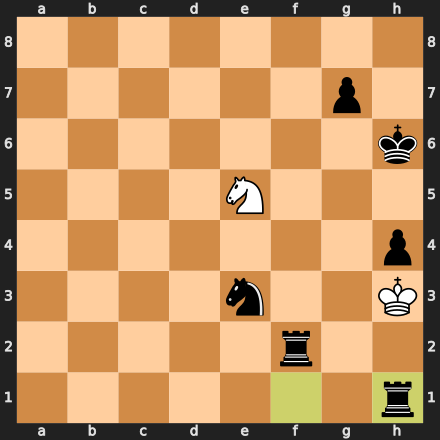

Game over: 0-1
To move: White
FEN: 8/6p1/7k/4N3/7p/4n2K/5r2/7r w - - 10 62
Moves: g3 Bxg3 fxg3 Ne2+ Kg2 Rd3 Nf3 Rxd1 Be3 Nexg3 b6 Nf1 Bg5 h6 b7 hxg5 Rc8 Rdd8 b8=Q Ne3+ Kg1 Rxc8 Qb3+ Nc4 Nxe5 Nf4 Nxc4 Ne2+ Kg2 Kh7 e5 Nf4+ Kh2 Rc5 Qc2+ Ng6 b4 Rc7 Qe2 Nf4 Qc2+ Kh6 Qe4 Ng6 Nd6 Rf4 Qe2 Nh4 e6 Nf3+ Kg3 Rc3 Qg2 Nh4+ Kh2 Nxg2 e7 Re3 b5 Rxe7 b6 Ne3 b7 Rb4 h4 gxh4 Kh3 Rd7 Ne4 Rdxb7 Nc5 Rf7 Nd3 Rb1 Kh2 Rbf1 Ne5 R7f2+ Kh3 Rh1#
Saved PGN: C:\Users\samue\Downloads\chess_play_outputs\dual1_self_play.pgn
[Event "Dual model self-play"]
[Site "Jupyter"]
[Date "????.??.??"]
[Round "?"]
[White "dual1 depth 5"]
[Black "dual1 depth 5"]
[Result "0-1"]

1. e4 e5 2. Nf3 Nc6 3. Bb5 a6 4. Ba4 Nf6 5. O-O Be7 6. Re1 b5 7. Bb3 d6 8. d4 Bg4 9. Bxf7+ Kxf7 10. dxe5 dxe5 11. Nbd2 Rf8 12. h3 Bxf3 13. Qxf3 Kg8 14. a4 Qe8 15. axb5 Nd4 16. Qd1 Qh5 17. Qxh5 Nxh5 18. Rxa6 Nxc2 19. Rd1 Rad8 20. Rc6 Nd4 21. Rxc7 Bh4 22. g3 Bxg3 23. fxg3 Ne2+ 24. Kg2 Rd3 25. Nf3 Rxd1 26. Be3 Nexg3 27. b6 Nf1 28. Bg5 h6 29. b7 hxg5 30. Rc8 Rdd8 

In [15]:
# Model vs itself
self_game = play_self_game(
    depth_white=5,
    depth_black=5,
    use_book=True,
    book_max_plies=OPENING_BOOK_PLIES,
    show=True,
    pause=0.05,
    top_k=1,
    temperature_cp=0.0,
    save_path=OUT_DIR / "dual1_self_play.pgn",
)
print(self_game)


## Run: model vs Stockfish

Set `STOCKFISH_PATH` in the config cell if Stockfish is not already on PATH, then run the next cell.


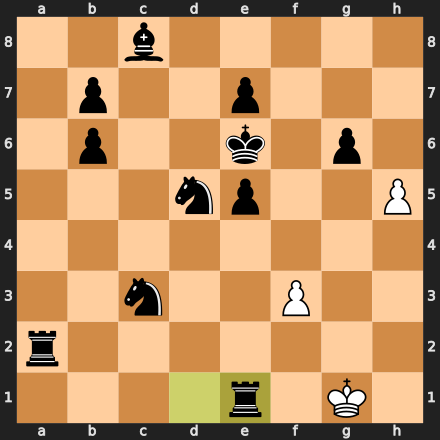

Game over: 0-1
To move: White
FEN: 2b5/1p2p3/1p2k1p1/3np2P/8/2n2P2/r7/4r1K1 w - - 0 32
Moves: e4 c5 Nf3 d6 d4 cxd4 Nxd4 g6 Bb5+ Nd7 Nc3 Nf6 Be3 Bg7 e5 dxe5 Ne6 fxe6 Bb6 axb6 Ne4 O-O Ng5 Nc5 Qxd8 Rxd8 Nf7 Kxf7 Bc4 Rd7 b4 Nce4 f3 Nc3 g4 Bh6 g5 Bxg5 Kf1 Bf4 Re1 Ra3 Bxe6+ Kxe6 Rg1 Rd4 Rxg6 hxg6 b5 Nxb5 c3 Nxc3 Kg1 Rxa2 h4 Nfd5 h5 Be3+ Rxe3 Rd1+ Re1 Rxe1#
Saved PGN: C:\Users\samue\Downloads\chess_play_outputs\dual1_vs_stockfish.pgn
[Event "Dual model vs Stockfish"]
[Site "Jupyter"]
[Date "????.??.??"]
[Round "1"]
[White "dual1 depth 3"]
[Black "Stockfish depth 8"]
[Result "0-1"]

1. e4 c5 2. Nf3 d6 3. d4 cxd4 4. Nxd4 g6 5. Bb5+ Nd7 6. Nc3 Nf6 7. Be3 Bg7 8. e5 dxe5 9. Ne6 fxe6 10. Bb6 axb6 11. Ne4 O-O 12. Ng5 Nc5 13. Qxd8 Rxd8 14. Nf7 Kxf7 15. Bc4 Rd7 16. b4 Nce4 17. f3 Nc3 18. g4 Bh6 19. g5 Bxg5 20. Kf1 Bf4 21. Re1 Ra3 22. Bxe6+ Kxe6 23. Rg1 Rd4 24. Rxg6 hxg6 25. b5 Nxb5 26. c3 Nxc3 27. Kg1 Rxa2 28. h4 Nfd5 29. h5 Be3+ 30. Rxe3 Rd1+ 31. Re1 Rxe1# 0-1


In [12]:
# Model vs Stockfish
stockfish_games = play_stockfish_match(
    n_games=1,
    my_color=chess.WHITE,
    alternate_colors=False,
    model_depth=3,
    stockfish_depth=8,
    use_book=True,
    show=True,
    pause=0.05,
    save_path=OUT_DIR / "dual1_vs_stockfish.pgn",
)
print(stockfish_games[0])


## Run: you vs the model

Run the next cell to play. Use SAN like `Nf3`, `O-O`, `exd5`, or UCI like `g1f3`. Commands during play: `undo`, `fen`, `quit`.


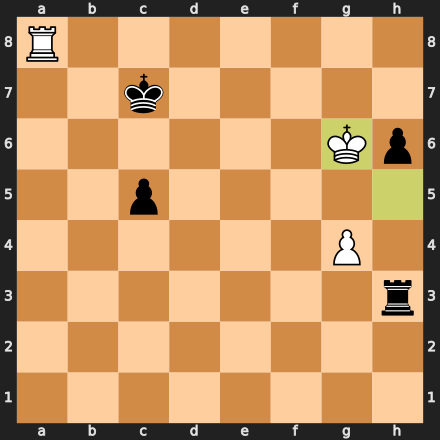

Game over: 1/2-1/2
To move: Black
FEN: R7/2k5/6Kp/2p5/6P1/7r/8/8 b - - 10 63
Moves: cxb4 cxb4 Bxb4 Re3 Ra5 Bd4 Bd2 Rd3 Bg5 Rc3 Bd2 Rc6 Ra4 Rc2 Rxd4 a4 Bb3 Rc6 Re6 Rc5 Rd5 Rxd5 Bxd5 hxg4 Be4 gxf5 Bxf5 Nf3 Be3 a5 Ra6 Kh2 Bg4 Kg3 Be6 Ra3 Bc5 Ra1 Be7 Nd4 Bc4 Kf4 Bd5 e6 Bc4 Ke5 c5 Rc1 Bd3 Nf5 Bxf5 Kxf5 Rxa5 Kg6 Ra4 g3 Rd4 Kf7 Kd8 Ra1 Bg5 Ra8+ Kc7 e7 Bxe7 Kxe7 Re4+ Kf6 Re3 g4 Rf3+ Kg6 Rg3 Kh5 Rh3+ Kg6 Rg3 Kh5 Rh3+ Kg6
Saved PGN: C:\Users\samue\Downloads\chess_play_outputs\human_vs_dual1.pgn
[Event "Human vs dual model"]
[Site "Jupyter"]
[Date "????.??.??"]
[Round "?"]
[White "Human"]
[Black "dual1 depth 3"]
[Result "1/2-1/2"]

1. e4 e5 2. Nc3 Nf6 3. f4 d5 4. fxe5 Nxe4 5. Qf3 Nc6 6. Nxe4 dxe4 7. Qxe4 Be6 8. Nf3 Qd7 9. Bb5 O-O-O 10. Bxc6 Qxc6 11. Qxc6 bxc6 12. c3 Be7 13. d4 Rhe8 14. Be3 f6 15. O-O Bc4 16. Rfe1 h6 17. Kh1 g5 18. h3 f5 19. b3 Be6 20. d5 Rxd5 21. Bxa7 c5 22. b4 g4 23. Ng1 cxb4 24. cxb4 Bxb4 25. Re3 Ra5 26. Bd4 Bd2 27. Rd3 Bg5 28. Rc3 Bd2 29. Rc6 Ra4 30. Rc2 Rxd4 31. a4 Bb3 32. Rc

In [29]:
# You vs model
human_game = play_me(
    human_color=chess.WHITE,
    model_depth=3,
    use_book=True,
    book_max_plies=OPENING_BOOK_PLIES,
    save_path=OUT_DIR / "human_vs_dual1.pgn",
)
if human_game is not None:
    print(human_game)


In [45]:
board = chess.Board('R7/2k5/6Kp/2p5/6P1/7r/8/8')
value_cp, logits = player.evaluate(board)
print(f"Initial value estimate: {value_cp:+.1f} cp")
print("Top policy moves:")
for mv in player.ordered_moves(board)[:8]:
    print(" ", board.san(mv), float(logits[move_to_index(mv)]))
value_cp, logits = player.evaluate(board)
print(f"Initial value estimate: {value_cp:+.1f} cp")
print("Top policy moves:")
for mv in player.ordered_moves(board)[:8]:
    print(" ", board.san(mv), float(logits[move_to_index(mv)]))

Initial value estimate: -53.6 cp
Top policy moves:
  Ra7+ 2.394407033920288
  g5 0.9917300939559937
  Kf5 0.6764583587646484
  Kf7 0.6482797861099243
  Kf6 0.6016629934310913
  Rh8 0.374735951423645
  Kg7 0.13207142055034637
  Ra6 0.13095052540302277
Initial value estimate: -53.6 cp
Top policy moves:
  Ra7+ 2.394407033920288
  g5 0.9917300939559937
  Kf5 0.6764583587646484
  Kf7 0.6482797861099243
  Kf6 0.6016629934310913
  Rh8 0.374735951423645
  Kg7 0.13207142055034637
  Ra6 0.13095052540302277
